In [2]:
from pathlib import Path
import gc
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações Globais
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_palette(["#1f77b4", "#ff7f0e", "#d62728"])

projeto_root = Path.cwd().parent

def plot_velocidade_controle_vs_processo(exp: str):
    exp_data_path = projeto_root / 'data' / 'processed_data' / 'eda_parquet' / f"eda_{exp}_4kHz.parquet"
    df = pd.read_parquet(exp_data_path)
    
    df['Tempo_Decorrido_s'] = df['Rul_s'].max() - df['Rul_s']
    df['Tempo_Decorrido_h'] = df['Tempo_Decorrido_s'] / 3600.0

    plt.figure(figsize=(12, 4))
    plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['setSpeed_rpm'].iloc[::100], label='Velocidade Nominal (Setpoint/Controle)', color='red', linewidth=2)
    plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['Speed_rpm'].iloc[::100], label='Velocidade Real Medida (Processo)', color='green', alpha=0.7)
    plt.title(f'Validação de Rotação - Ensaio {exp}')
    plt.xlabel('Tempo de Operação (h)')
    plt.ylabel('Velocidade (RPM)')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    del df
    gc.collect()

def plot_distribuicao_velocidade(exp: str):
    exp_data_path = projeto_root / 'data' / 'processed_data' / 'eda_parquet' / f"eda_{exp}_4kHz.parquet"
    df = pd.read_parquet(exp_data_path)
    plt.figure(figsize=(12, 4))
    df_sample = df.sample(n=min(100000, len(df)), random_state=42)

    sns.kdeplot(data=df_sample, x='Speed_rpm', fill=True, color="green", label='Velocidade Real (Amostra)', bw_adjust=0.6, alpha=0.4)
    sns.kdeplot(data=df_sample, x='setSpeed_rpm', color="red", linestyle="--", linewidth=2, label='Velocidade Nominal', bw_adjust=0.3)

    ax = plt.gca()
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0,0)) # Força a notação para qualquer valor
    ax.yaxis.set_major_formatter(formatter)

    plt.title(f'Distribuição de Rotação (Amostragem Otimizada) - Exp {exp}')
    plt.xlabel('Velocidade (RPM)')
    plt.ylabel('Densidade')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    
    del df, df_sample
    gc.collect()

def plot_termodinamica(exp: str):
    exp_data_path = projeto_root / 'data' / 'processed_data' / 'eda_parquet' / f"eda_{exp}_4kHz.parquet"
    df = pd.read_parquet(exp_data_path)
    
    df['Tempo_Decorrido_s'] = df['Rul_s'].max() - df['Rul_s']
    df['Tempo_Decorrido_h'] = df['Tempo_Decorrido_s'] / 3600.0

    plt.figure(figsize=(12, 4))
    plt.plot(df['Tempo_Decorrido_h'].iloc[::64000], df['TempT1_C'].iloc[::64000], label='Temperatura T1 (Processo)', color='blue')
    plt.plot(df['Tempo_Decorrido_h'].iloc[::64000], df['TempT2_C'].iloc[::64000], label='Temperatura T2 (Processo)', color='orange')
    plt.axhline(y=110, color='red', linestyle='--', linewidth=2, label='Limiar de Falha Funcional (110°C)')
    plt.title(f'Evolução Termodinâmica do Rolamento - Ensaio {exp}')
    plt.xlabel('Tempo de Operação (h)')
    plt.ylabel('Temperatura Absoluta (°C)')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    del df
    gc.collect()

def plot_cinematica_picos(exp: str):
    exp_data_path = projeto_root / 'data' / 'processed_data' / 'eda_parquet' / f"eda_{exp}_4kHz.parquet"
    df = pd.read_parquet(exp_data_path)
    
    df['Tempo_Decorrido_s'] = df['Rul_s'].max() - df['Rul_s']
    df['Tempo_Decorrido_h'] = df['Tempo_Decorrido_s'] / 3600.0

    df['abs_AccelA_g'] = df['AccelA_g'].abs()
    df['AccelA_Peak'] = df['abs_AccelA_g'].rolling(window=3200).max(engine='cython')
    df['AccelA_Trend'] = df['AccelA_Peak'].rolling(window=64000).mean(engine='cython')

    plt.figure(figsize=(12, 5))
    plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['AccelA_g'].iloc[::100], color='lightgray', alpha=0.3, label='Vibração Original')
    plt.plot(df['Tempo_Decorrido_h'].iloc[::100], df['AccelA_Trend'].iloc[::100], color='navy', linewidth=2, label='Tendência (Média dos Picos)')
    plt.axhline(y=10, color='red', linestyle='-', linewidth=2, label='Limite Crítico (10g)')
    plt.ylim(bottom=-6) 
    plt.title(f'Tendência de Longo Prazo da Amplitude de Pico - Exp {exp}')
    plt.xlabel('Tempo (h)')
    plt.ylabel('Aceleração (g)')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    del df
    gc.collect()

def plot_intervalo_temporal(exp: str):
    exp_data_path = projeto_root / 'data' / 'processed_data' / 'eda_parquet' / f"eda_{exp}_4kHz.parquet"
    df = pd.read_parquet(exp_data_path)
    
    df['Tempo_Decorrido_s'] = df['Rul_s'].max() - df['Rul_s']
    
    delta_s = df['Tempo_Decorrido_s'].diff().fillna(0)
    df_gaps = df[delta_s > 1.0].copy()
    df_gaps['delta_min'] = delta_s[delta_s > 1.0] / 60.0
    df_gaps['delta_mmss'] = df_gaps['delta_min'].apply(lambda x: f"{int(x * 60) // 60:02d}:{int(x * 60) % 60:02d}")

    plt.figure(figsize=(12, 4))
    medicoes_idx = np.arange(len(df_gaps))

    plt.plot(medicoes_idx, df_gaps['delta_min'], marker='o', linestyle='-', markersize=4, color='teal', alpha=0.7)
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

    for idx, value, label in zip(medicoes_idx, df_gaps['delta_min'], df_gaps['delta_mmss']):
        if value > 1.0:
            plt.text(float(idx), float(value) + 0.1, label, fontsize=9, ha='center', va='bottom', color='darkred', weight='bold')

    plt.xlabel('Índice da Aquisição (Sequencial)')
    plt.ylabel('Intervalo Temporal (min)')
    plt.title(f'Intervalo Temporal entre Aquisições Consecutivas - Ensaio {exp}')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    del df, df_gaps, delta_s, medicoes_idx
    gc.collect()
    
def plot_results(exp: str):
    predictions_path = projeto_root / 'results' / f'val_{exp}' / 'validation_predictions.csv'
    mse_path = projeto_root / 'results' / f'val_{exp}' / 'training_history.csv'    
    
    mse_df = pd.read_csv(mse_path)
    min_mse_value = mse_df['val_mse'].min()
    min_mse_epoch = int(mse_df[mse_df['val_mse'] == min_mse_value]['epoch'].iloc[0])
    
    df = pd.read_csv(predictions_path)
    
    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df['target_seconds']/3600, label='RUL real', color='red', linewidth=2)
    plt.plot(df.index, df['prediction_seconds']/3600, 
             label=f'Predição na época {min_mse_epoch} (MSE: {min_mse_value:.3f})', 
             color='blue', alpha=0.85)
             
    plt.title(f'Vida Útil Remanescente (RUL) Predita x Real - Ensaio {exp}')
    plt.xlabel('Ciclos de Medição')
    plt.ylabel('RUL [h]')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

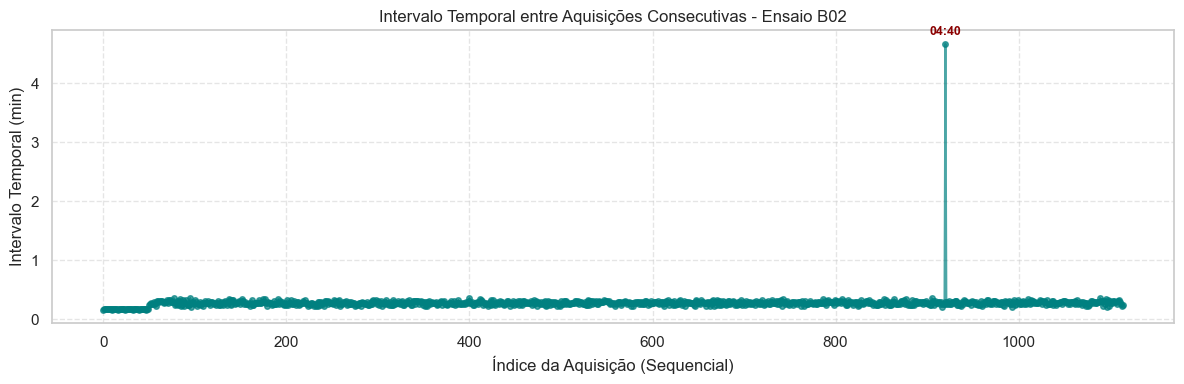

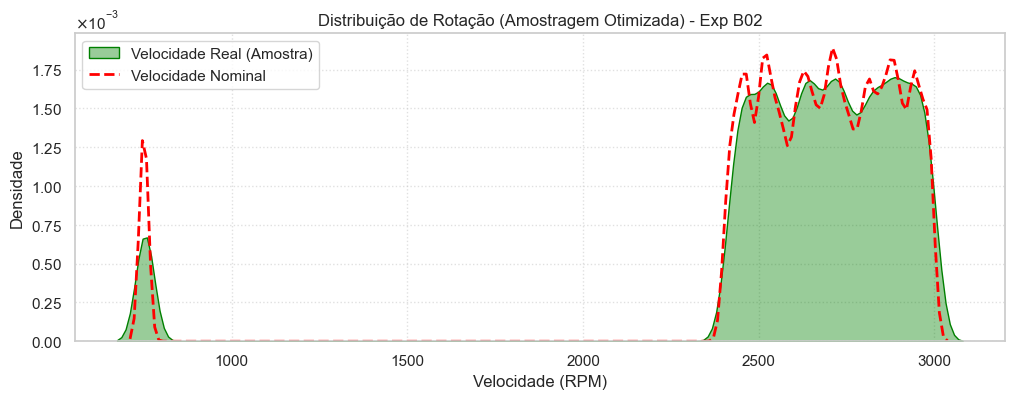

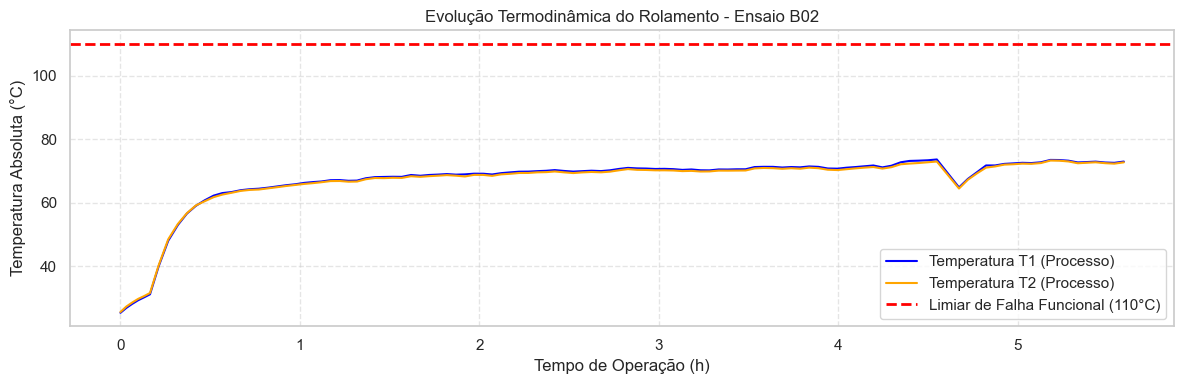

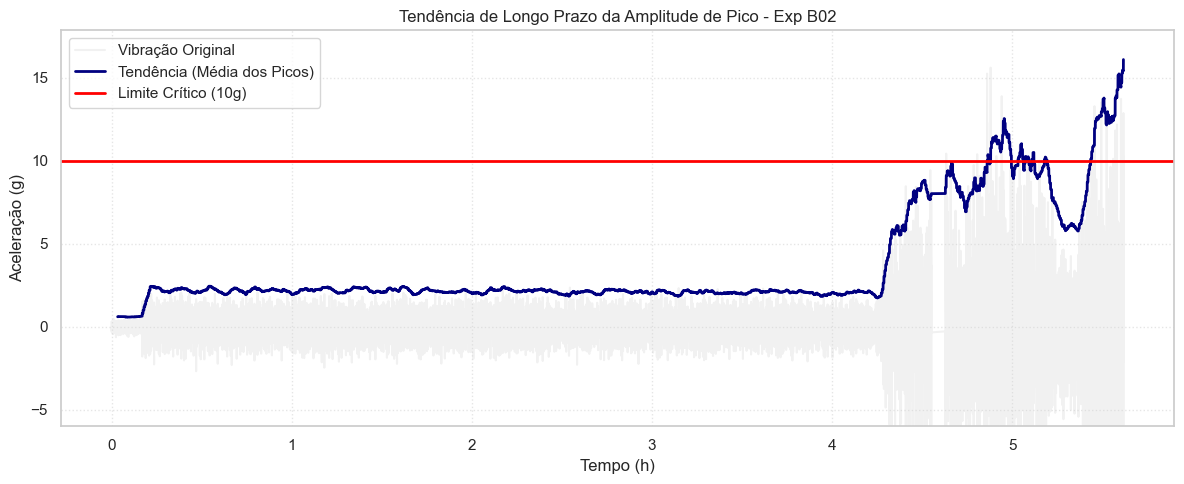

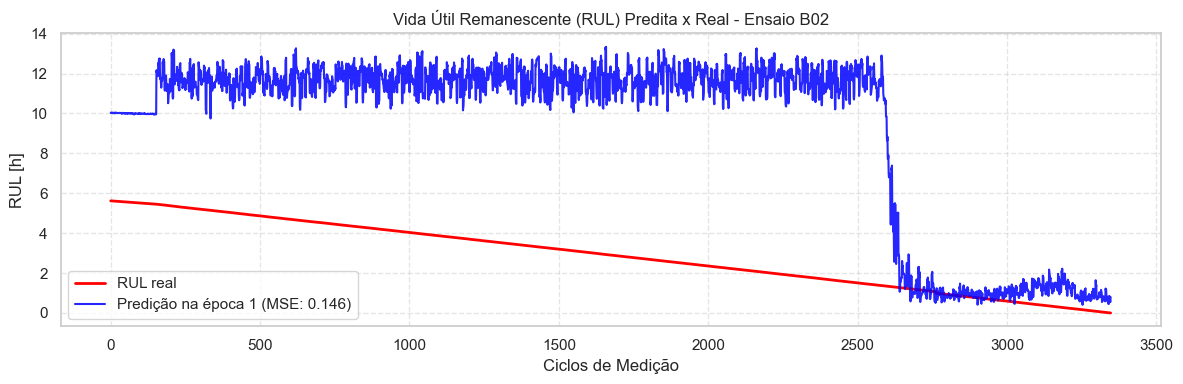

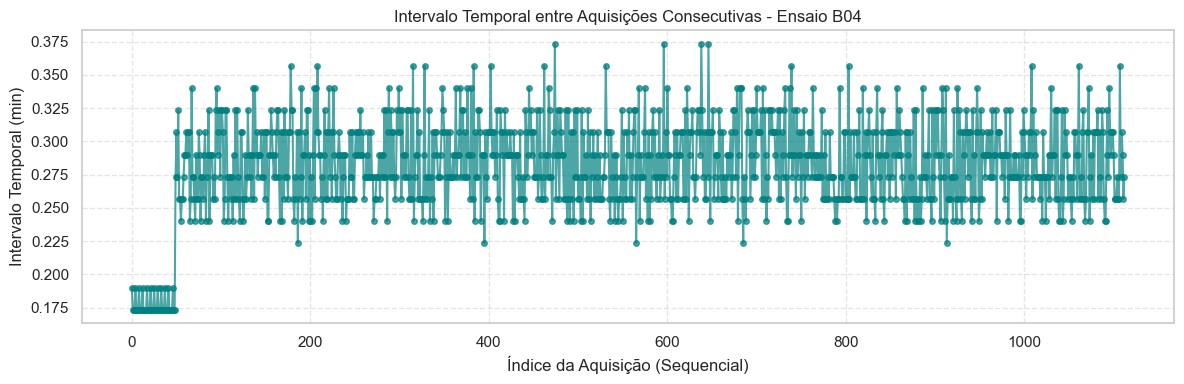

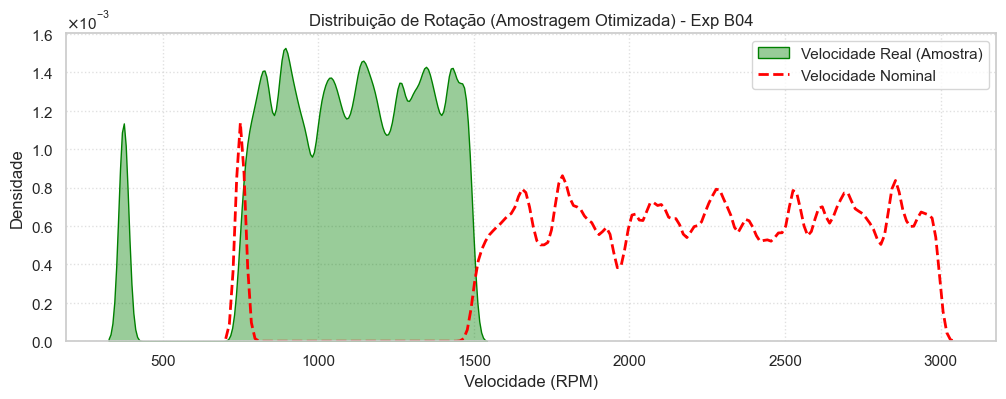

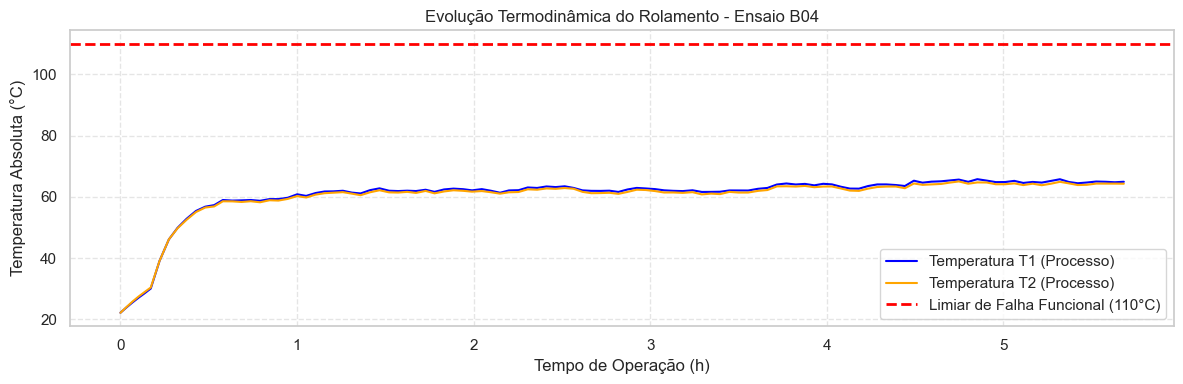

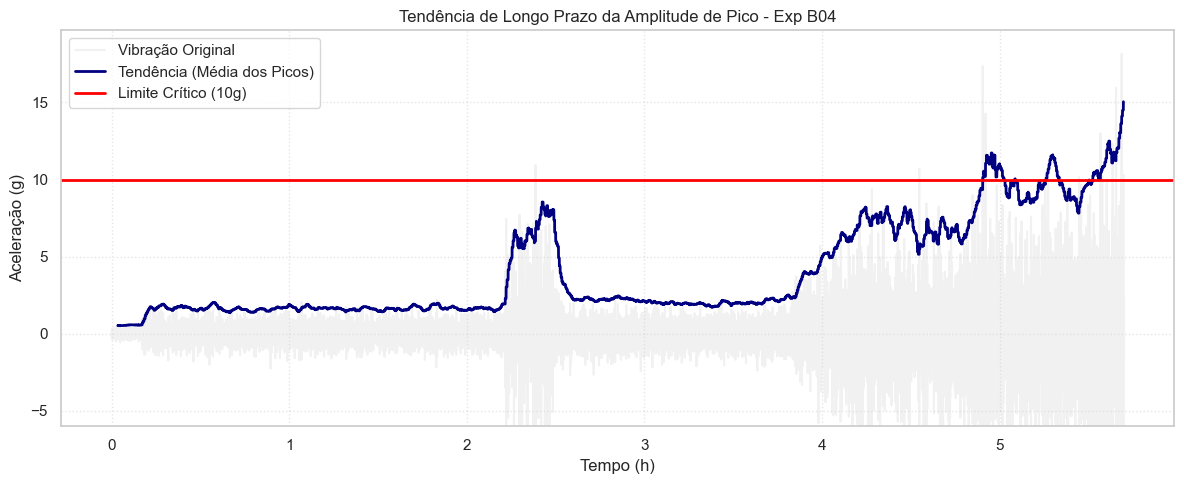

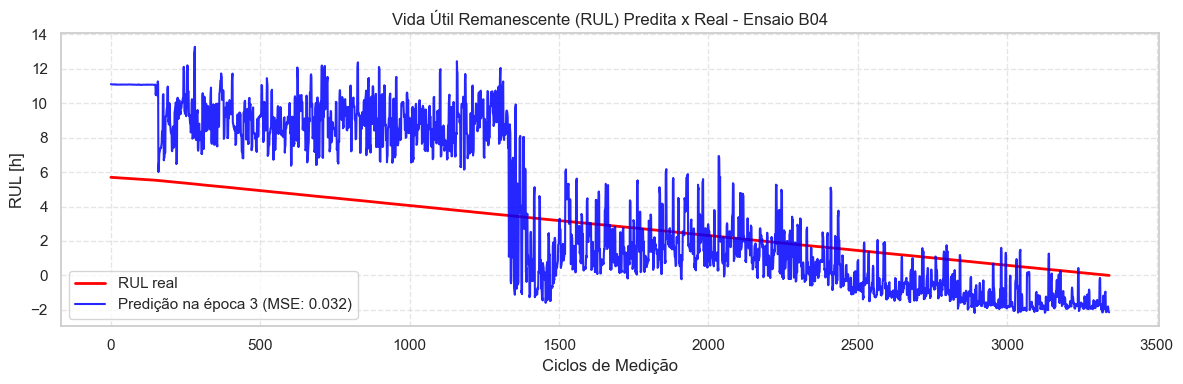

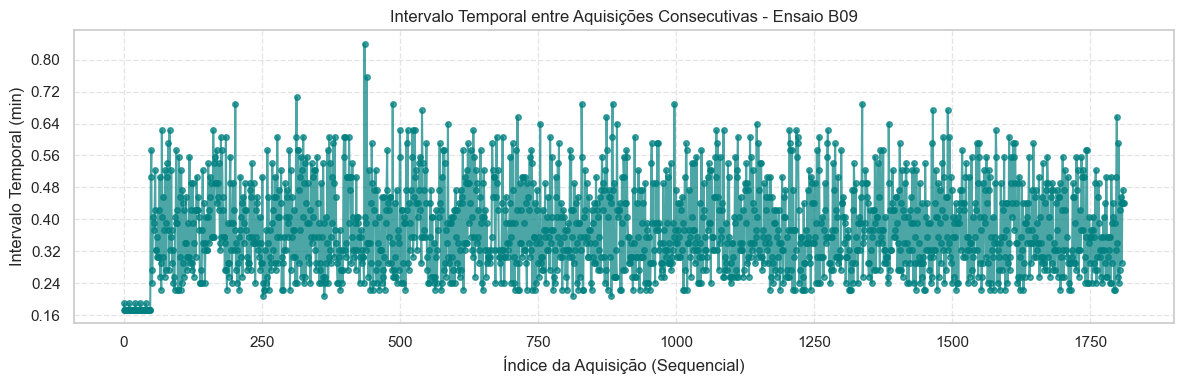

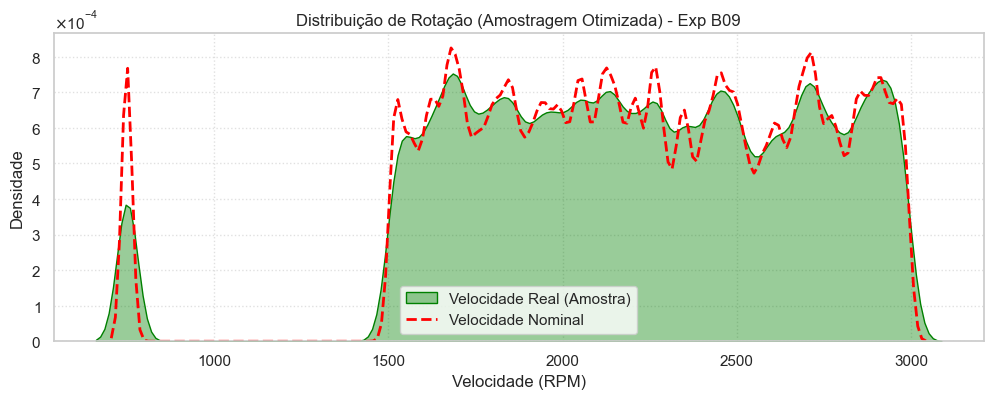

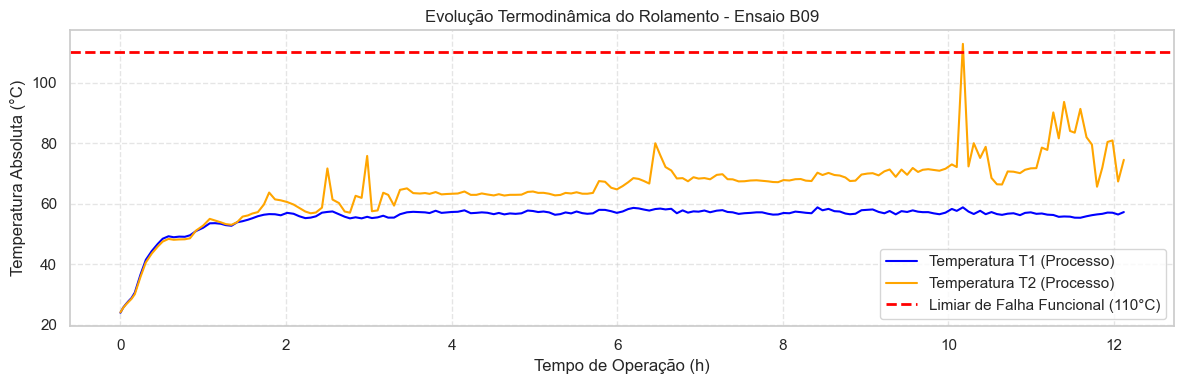

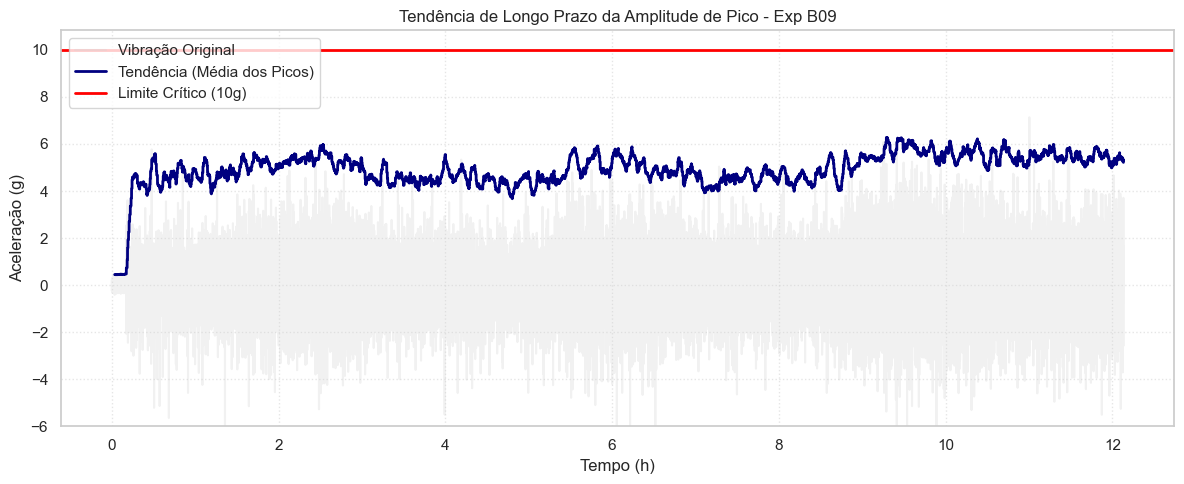

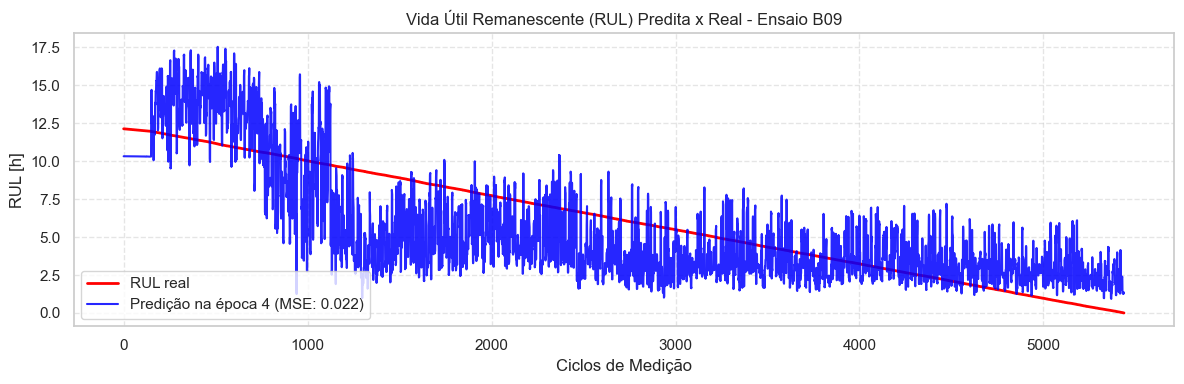

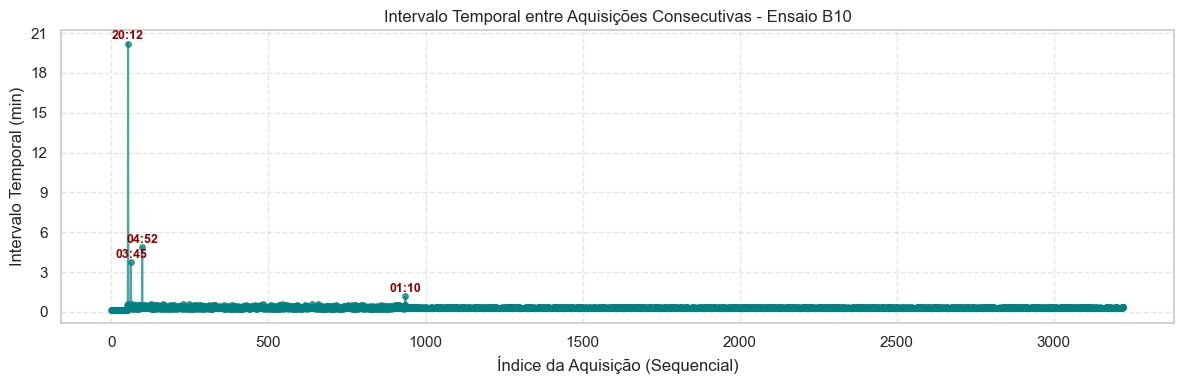

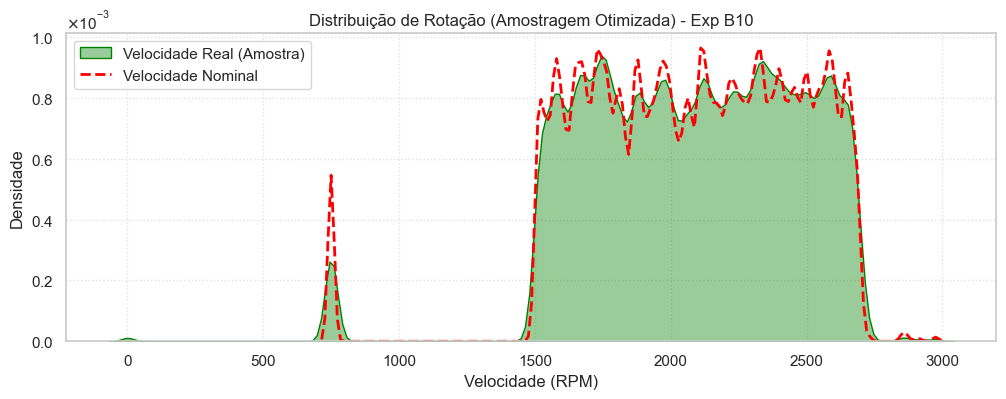

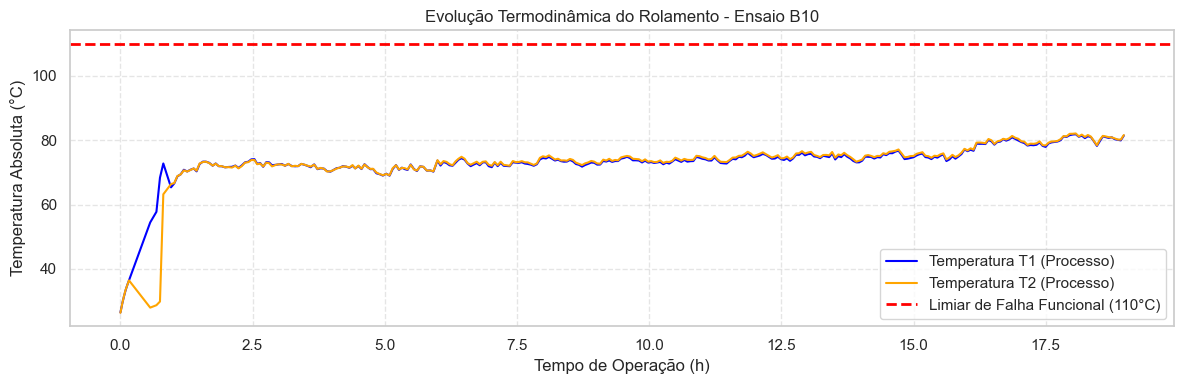

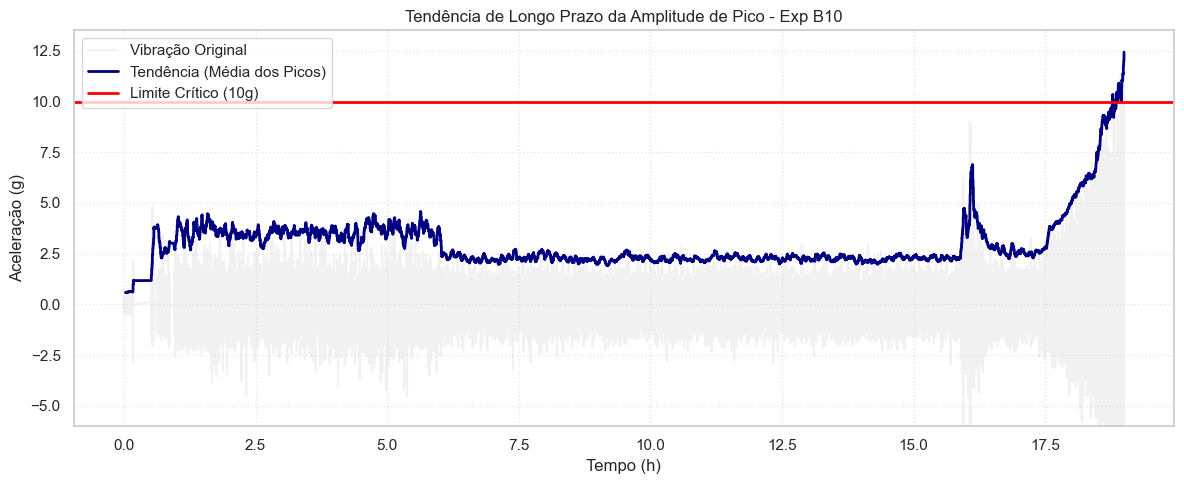

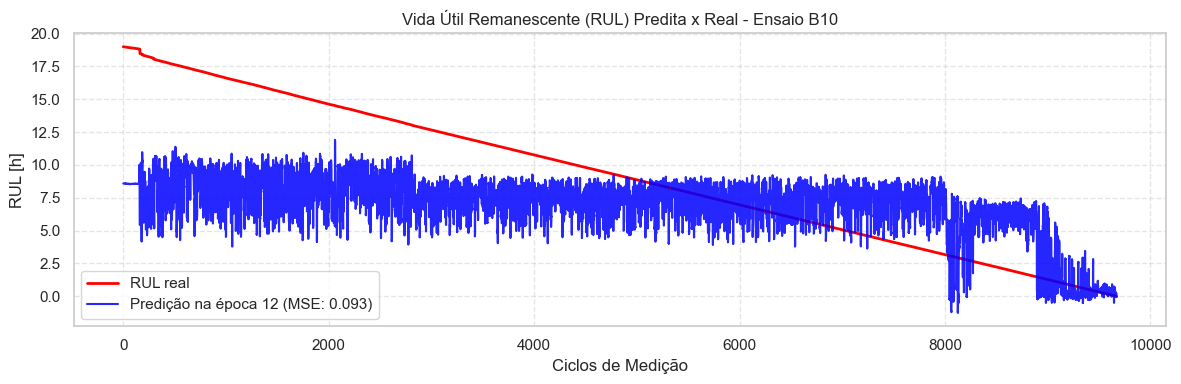

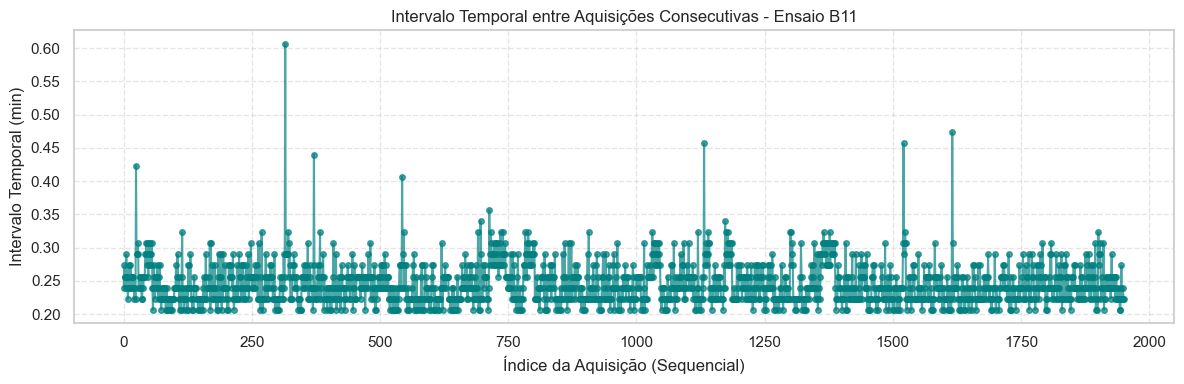

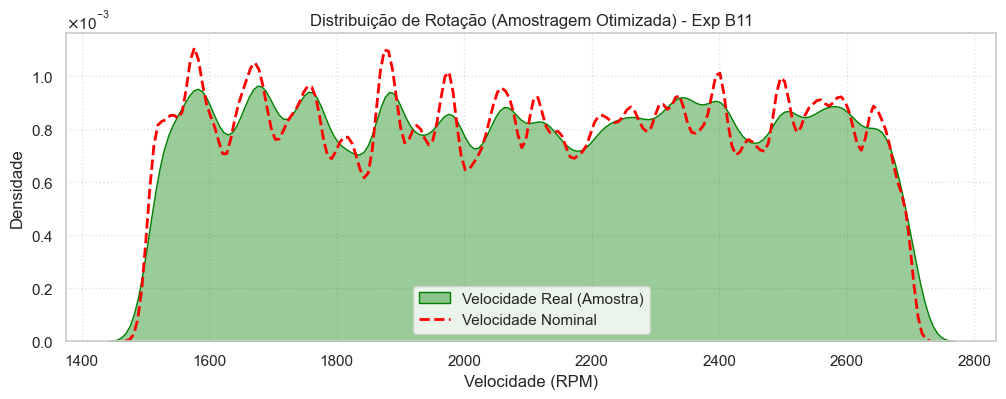

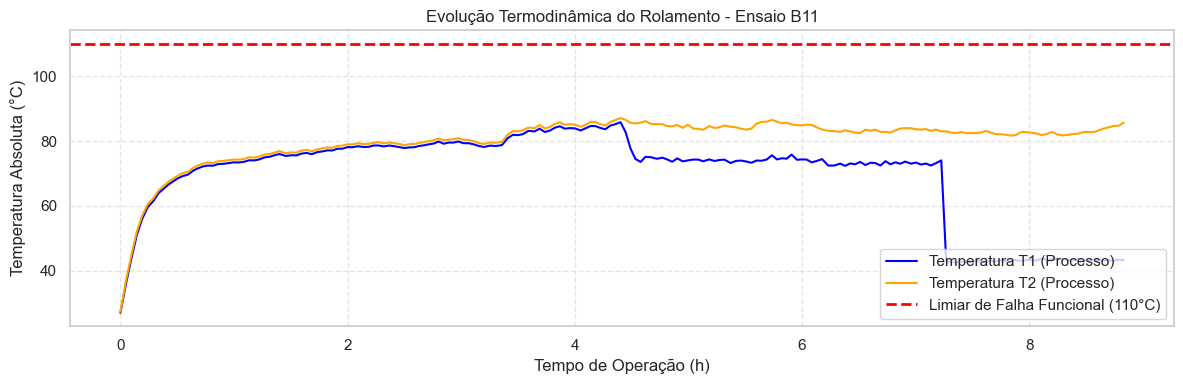

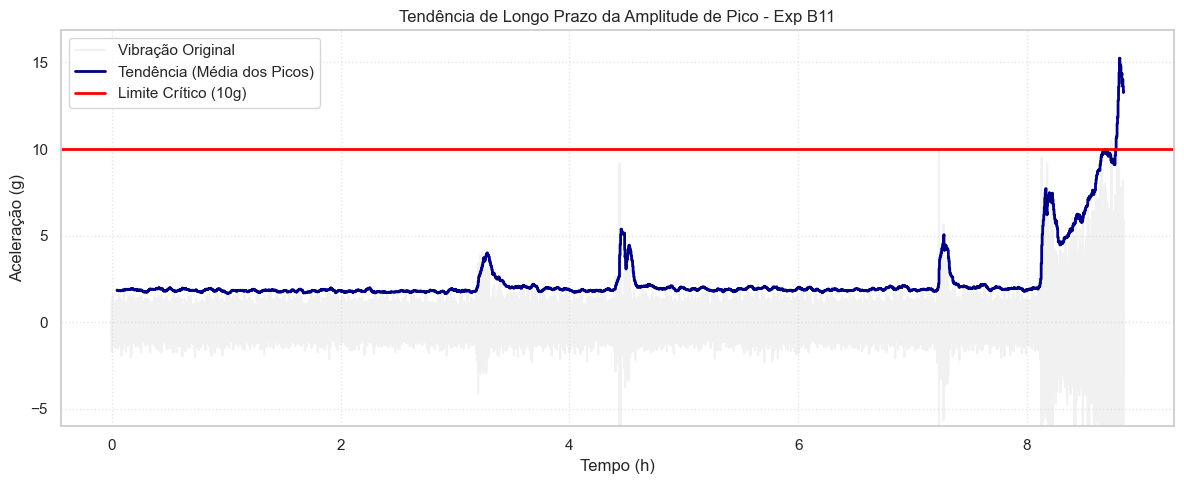

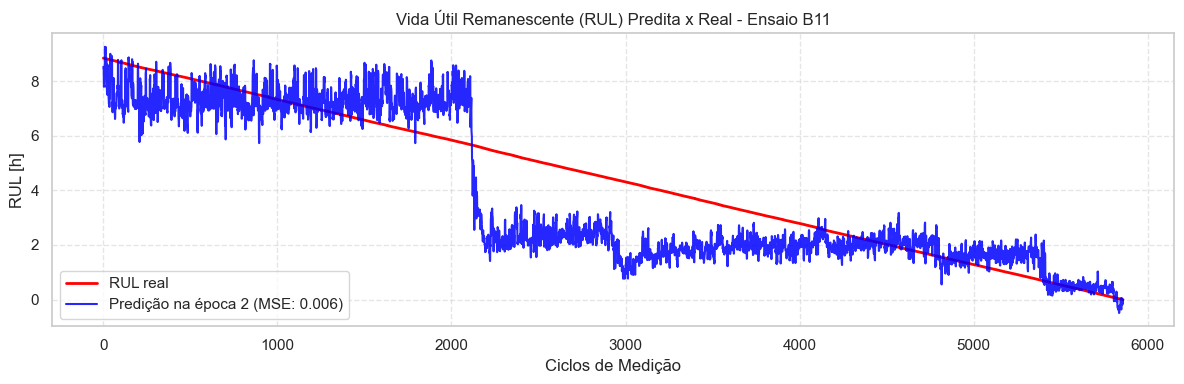

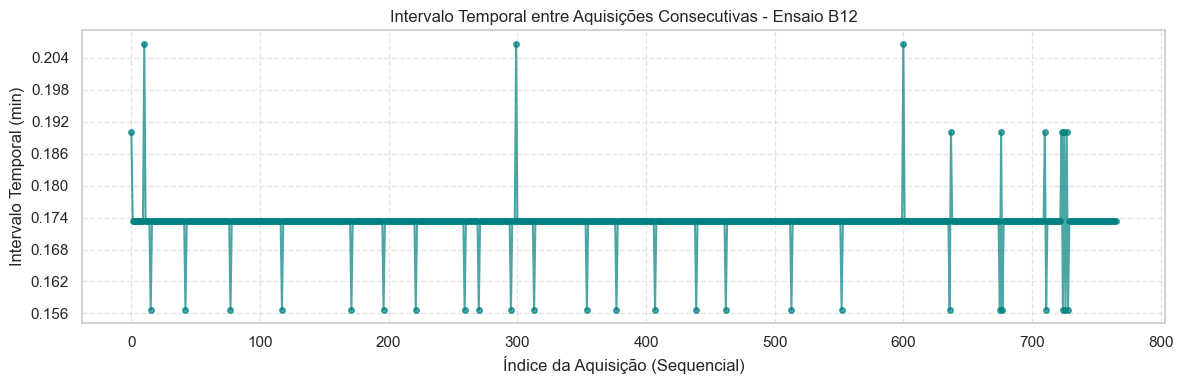

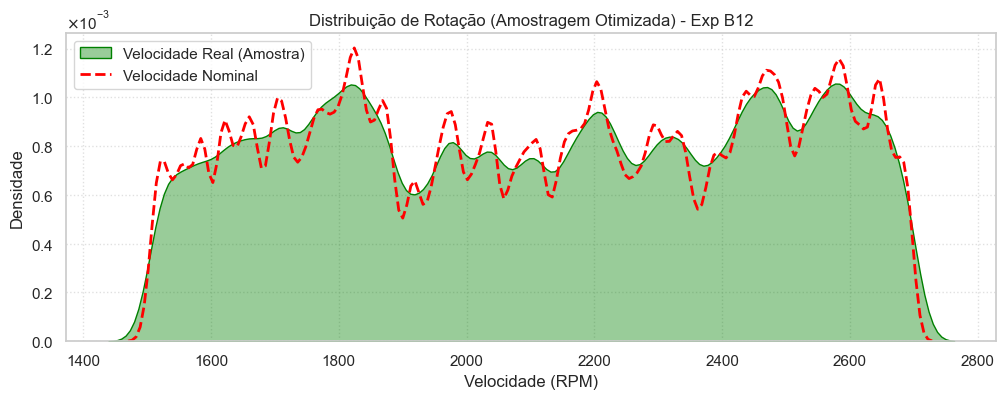

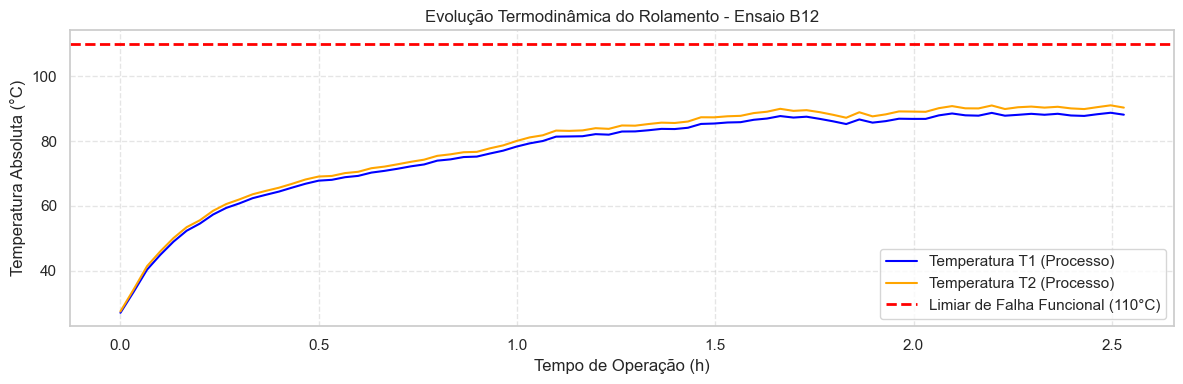

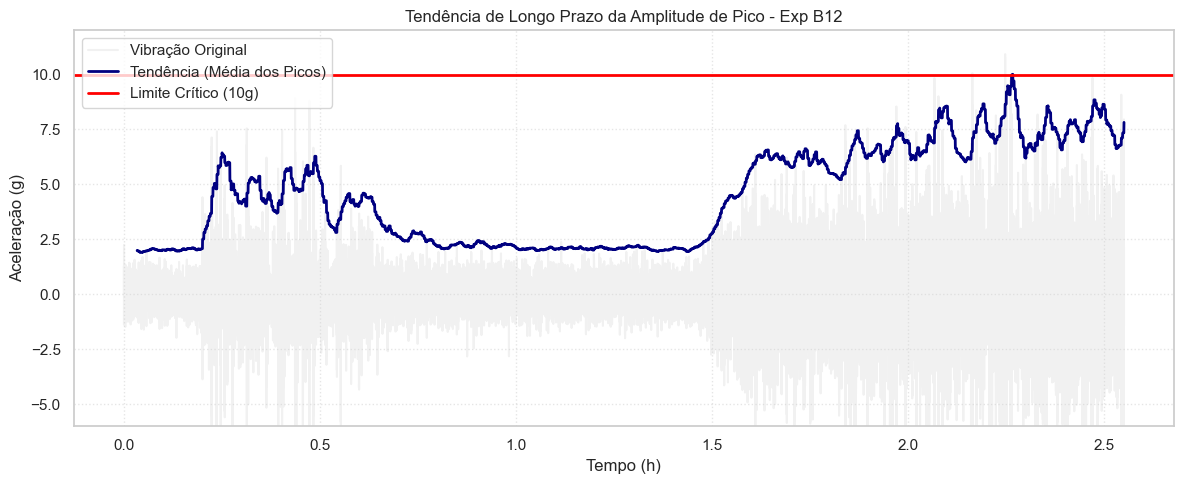

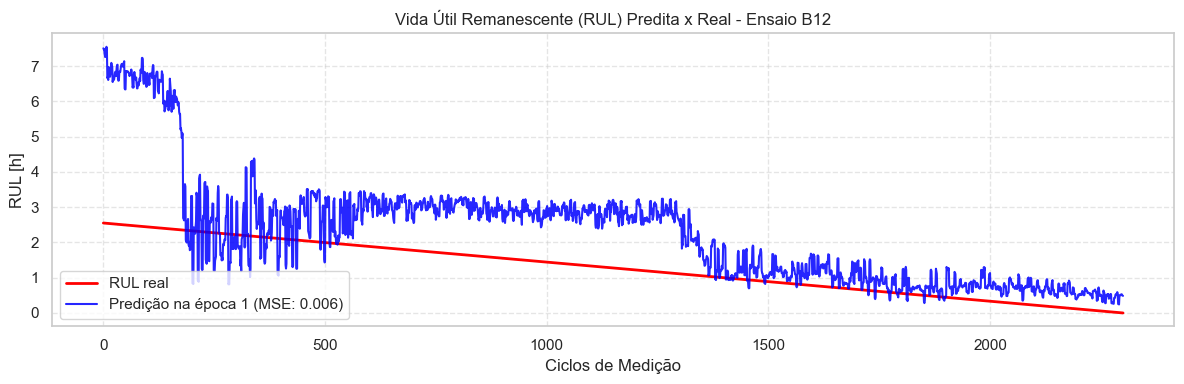

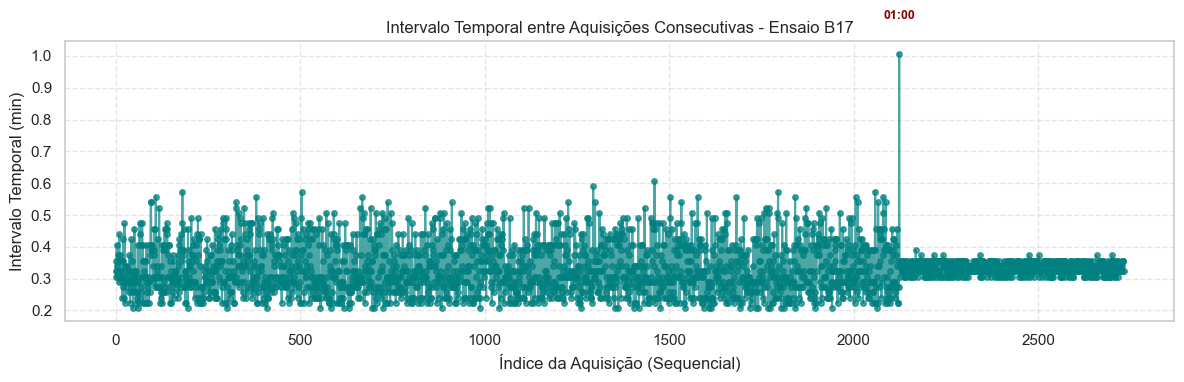

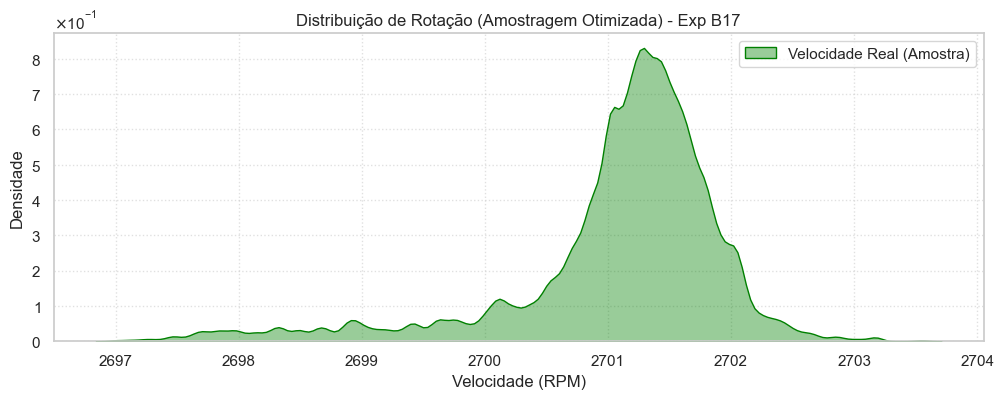

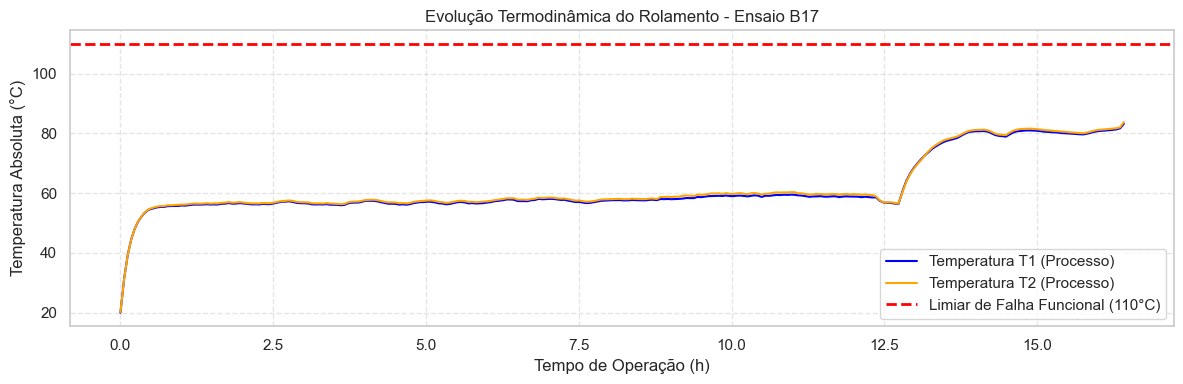

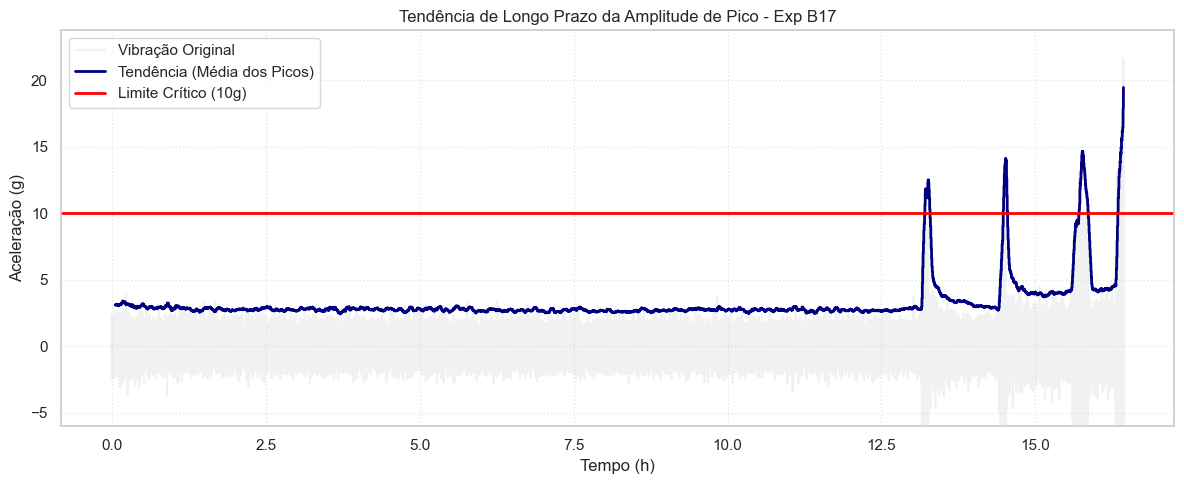

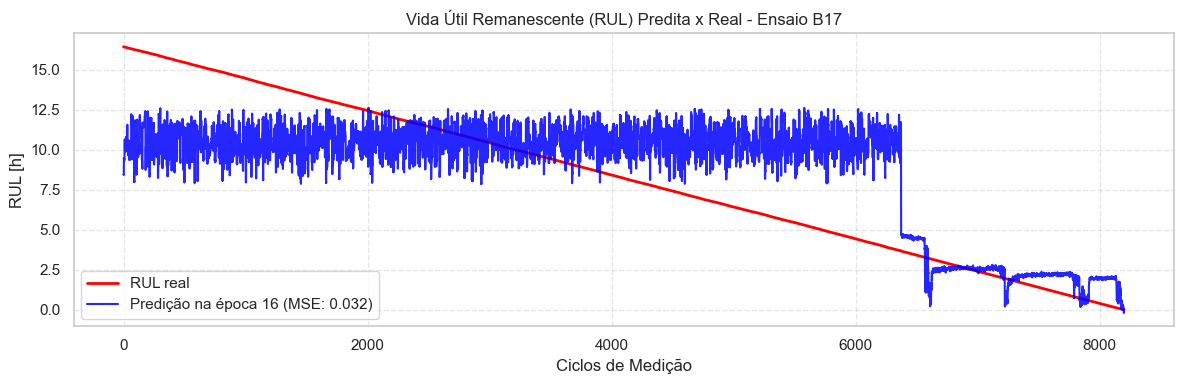

In [11]:
ensaios_all = ["B02", "B04", "B09", "B10", "B11", "B12", "B17"]

for ensaio in ensaios_all:
    plot_intervalo_temporal(ensaio)
    plot_distribuicao_velocidade(ensaio)
    plot_termodinamica(ensaio)
    plot_cinematica_picos(ensaio)
    plot_results(ensaio)
    
    

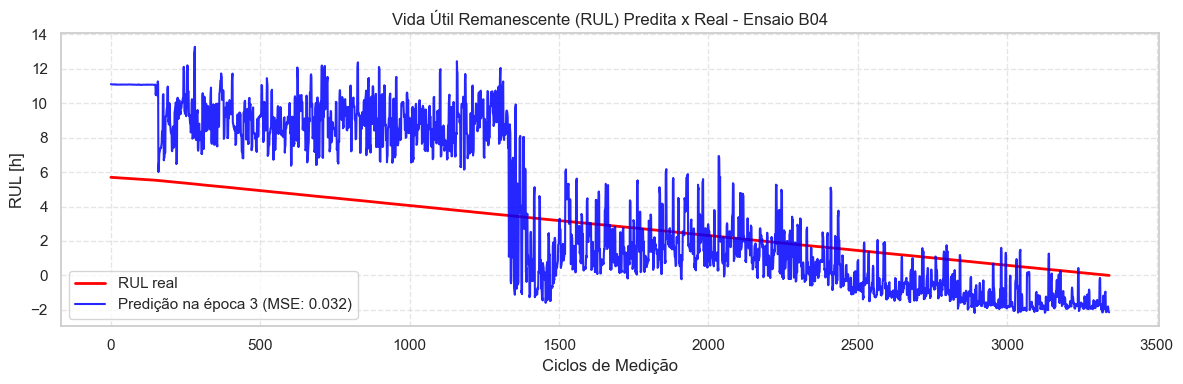

In [9]:
ensaio = 'B04'
plot_results(ensaio)